# Probando ML de FastF1

### Instalar librerias

In [1]:
%pip install fastf1 polars pandas xgboost scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Ingesta

In [3]:
import os
import fastf1
import time
import pandas as pd
import polars as pl
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from fastf1.exceptions import RateLimitExceededError
import logging

# Configuración de logs y cache
logging.basicConfig(level=logging.INFO)
cache_dir = 'cache/'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
fastf1.Cache.enable_cache(cache_dir)

class F1DataIngestor:
    def __init__(self, cache_dir='cache/'):
        self.cache_dir = cache_dir

    def fetch_season_data(self, year):
        all_laps = []
        # El schedule suele estar en cache, pero lo envolvemos por si acaso
        try:
            schedule = fastf1.get_event_schedule(year)
        except RateLimitExceededError:
            print("Límite alcanzado al obtener el calendario. Esperando 60s...")
            time.sleep(60)
            schedule = fastf1.get_event_schedule(year)

        events = schedule[schedule['EventFormat'] != 'testing']
        
        for _, event in events.iterrows():
            success = False
            retries = 0
            max_retries = 5
            
            while not success and retries < max_retries:
                try:
                    print(f"Cargando: {year} - {event['EventName']} (Intento {retries + 1})")
                    session = fastf1.get_session(year, event['RoundNumber'], 'R')
                    
                    # telemetry=False es vital para no saturar la API con miles de archivos
                    session.load(laps=True, telemetry=False, weather=True) 
                    
                    laps = session.laps.copy()
                    laps['Year'] = year
                    laps['EventName'] = event['EventName']
                    laps['TrackType'] = self._get_track_type(event['EventName'])
                    
                    weather = session.weather_data
                    if not weather.empty:
                        laps['TrackTemp'] = weather['TrackTemp'].mean()
                        laps['Rainfall'] = 1 if weather['Rainfall'].any() else 0
                    else:
                        laps['TrackTemp'], laps['Rainfall'] = 35.0, 0
                    
                    all_laps.append(laps)
                    success = True
                    # Pequeña pausa entre carreras para ser "buenos ciudadanos" con el servidor
                    time.sleep(2) 

                except RateLimitExceededError:
                    retries += 1
                    wait_time = 60 * retries # Aumenta la espera en cada reintento
                    print(f"¡Bloqueo de API! Pausando {wait_time} segundos...")
                    time.sleep(wait_time)
                
                except Exception as e:
                    print(f"Error omitiendo {event['EventName']}: {e}")
                    break # Si es un error distinto al límite, saltamos la carrera
                
        return pd.concat(all_laps, ignore_index=True) if all_laps else pd.DataFrame()

    def fetch_multiple_seasons(self, years_list, output_file='dataset_f1_multiaño_raw.csv'):
        for year in years_list:
            # Verificamos si el año ya está descargado en el CSV para no repetir
            if os.path.exists(output_file):
                df_existing = pd.read_csv(output_file)
                if 'Year' in df_existing.columns and year in df_existing['Year'].unique():
                    print(f"--- Temporada {year} ya existe en el archivo. Saltando... ---")
                    continue

            print(f"\n=== INICIANDO DESCARGA TEMPORADA {year} ===")
            year_df = self.fetch_season_data(year)
            
            if not year_df.empty:
                # Si el archivo no existe, lo creamos. Si existe, añadimos (append)
                header = not os.path.exists(output_file)
                year_df.to_csv(output_file, mode='a', index=False, header=header)
                print(f"--- Temporada {year} guardada correctamente ---")
            
            print("Pausa de seguridad entre temporadas...")
            time.sleep(10)

        return pd.read_csv(output_file) if os.path.exists(output_file) else pd.DataFrame()

    def _get_track_type(self, event_name):
        street = ['Monaco', 'Singapore', 'Baku', 'Jeddah', 'Las Vegas', 'Australia', 'Miami']
        return 'Street' if any(s in event_name for s in street) else 'Permanent'

# --- EJECUCIÓN ---
ingestor = F1DataIngestor()
años_a_descargar = [2020, 2021, 2022, 2023, 2024] 

# Esta función ahora gestiona todo: reintentos, esperas y guardado incremental
data_raw = ingestor.fetch_multiple_seasons(años_a_descargar)

print(f"\nProceso finalizado. Total de vueltas en el dataset: {len(data_raw)}")

--- Temporada 2020 ya existe en el archivo. Saltando... ---
--- Temporada 2021 ya existe en el archivo. Saltando... ---
--- Temporada 2022 ya existe en el archivo. Saltando... ---
--- Temporada 2023 ya existe en el archivo. Saltando... ---
--- Temporada 2024 ya existe en el archivo. Saltando... ---

Proceso finalizado. Total de vueltas en el dataset: 116707


### Ingenieria de datos

In [5]:
# --- CELDA: INGENIERÍA DE FEATURES ---
print("Procesando Features con Polars...")

def build_ml_dataset(raw_df):
    # 1. Limpieza previa en Pandas
    df_temp = raw_df.copy()
    # Aseguramos que PitOutTime también esté para identificar OutLaps
    for col in ['LapTime', 'PitInTime', 'PitOutTime']:
        df_temp[col] = pd.to_timedelta(df_temp[col], errors='coerce')

    # 2. Pasamos a Polars Lazy
    df_pl = pl.from_pandas(df_temp).lazy()
    
    return (
        df_pl
        # 3. Identificar tipo de vuelta ANTES de convertir tiempos a float
        .with_columns([
            pl.when(pl.col("PitInTime").is_not_null()).then(pl.lit("InLap"))
            .when(pl.col("PitOutTime").is_not_null()).then(pl.lit("OutLap"))
            .otherwise(pl.lit("Racing"))
            .alias("PitStatus")
        ])
        # 4. Preparación de tipos básicos
        .with_columns([
            (pl.col("LapTime").dt.total_milliseconds().cast(pl.Float64) / 1000).alias("LapTime"),
            pl.col("TyreLife").cast(pl.Float32),
            pl.col("Compound").cast(pl.Categorical),
            pl.col("TrackType").cast(pl.Categorical),
            pl.col("TrackTemp").cast(pl.Float32),
            pl.col("Rainfall").cast(pl.Int8)
        ])
        # 5. CÁLCULO DE PÉRDIDA ESTIMADA (Feature Engineering Pro)
        .with_columns([
            # Calculamos la media de vueltas de carrera (excluyendo In/Out laps) por GP
            pl.col("LapTime").filter(pl.col("PitStatus") == "Racing")
            .mean().over(["Year", "EventName"])
            .alias("AvgCleanLapTime")
        ])
        .with_columns([
            # Si es vuelta de box, restamos la media para ver cuánto se pierde en el Pit Lane
            pl.when(pl.col("PitStatus") != "Racing")
            .then(pl.col("LapTime") - pl.col("AvgCleanLapTime"))
            .otherwise(0.0)
            .alias("EstimatedPitLoss")
        ])
        # 6. Ingeniería de Rendimiento e Historial
        .with_columns([
            (pl.col("LapTime") - pl.col("LapTime").shift(1))
                .over(["Year", "EventName", "Driver"]).alias("LapDelta"),
            pl.col("LapTime").rolling_mean(window_size=3)
                .over(["Year", "EventName", "Driver"]).alias("RollingLapTime"),
            # Nueva Feature: ¿Viene el piloto de haber parado justo ahora?
            pl.col("PitStatus").shift(1).fill_null("Racing").alias("PrevLapStatus")
        ])
        # 7. TARGETS
        .with_columns([
            pl.col("PitInTime").is_not_null().shift(-1).fill_null(False).cast(pl.Int8).alias("target_pit"),
            pl.when(pl.col("LapTime") > pl.col("AvgCleanLapTime") * 1.3)
                .then(1).otherwise(0).alias("sc_event")
        ])
        # 8. Target SC
        .with_columns([
            pl.col("sc_event").shift(-5).rolling_max(window_size=5).fill_null(0).alias("target_sc_upcoming")
        ])
        .collect()
    ).to_pandas()

# Ejecutar el procesamiento
dataset = build_ml_dataset(data_raw)
# Limpiamos NaNs
dataset = dataset.dropna(subset=['LapDelta', 'RollingLapTime', 'AvgCleanLapTime'])
print(f"Dataset preparado: {dataset.shape[0]} vueltas listas para entrenar.")

Procesando Features con Polars...
Dataset preparado: 108900 vueltas listas para entrenar.


# Entrenamiento

In [6]:
# --- CELDA: ENTRENAMIENTO Y EVALUACIÓN (VERSION PRO) ---
import numpy as np
import matplotlib.pyplot as plt

# 1. ACTUALIZACIÓN DE FEATURES: Incluimos las nuevas columnas
features = [
    'Year', 'TyreLife', 'LapTime', 'LapDelta', 'RollingLapTime', 
    'TrackTemp', 'Rainfall', 'TrackType', 'Compound', 
    'EstimatedPitLoss', 'PrevLapStatus'  # <--- LAS CLAVES NUEVAS
]

X = dataset[features].copy()
y = dataset['target_pit']

# Asegurar categorías (XGBoost necesita saber cuáles son texto/categoría)
categorical_cols = ['Compound', 'TrackType', 'PrevLapStatus']
for col in categorical_cols:
    X[col] = X[col].astype('category')

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. AJUSTE DE RATIO: 
# Usamos el ratio completo para no perder Recall, pero puedes probar ratio * 0.7 
# si ves que hay demasiados falsos positivos.
count_normal = np.sum(y_train == 0)
count_pit = np.sum(y_train == 1)
ratio = count_normal / count_pit
print(f"Ratio de desequilibrio: {ratio:.2f}")

# 3. ENTRENAMIENTO
print("Entrenando con Features enriquecidas...")
model_pit = xgb.XGBClassifier(
    enable_categorical=True, 
    n_estimators=250,      # Un poco más de árboles para procesar las nuevas features
    learning_rate=0.04,
    max_depth=7,
    scale_pos_weight=ratio, 
    objective='binary:logistic',
    random_state=42
)

model_pit.fit(X_train, y_train)

# 4. EVALUACIÓN
y_pred = model_pit.predict(X_test)

print("\n" + "="*40)
print("RESULTADOS DEL MODELO FINAL")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Ratio de desequilibrio: 28.03
Entrenando con Features enriquecidas...

RESULTADOS DEL MODELO FINAL
Accuracy: 0.7973

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.99      0.80      0.88     21030
           1       0.11      0.69      0.19       750

    accuracy                           0.80     21780
   macro avg       0.55      0.75      0.54     21780
weighted avg       0.96      0.80      0.86     21780



### Importancia de variables

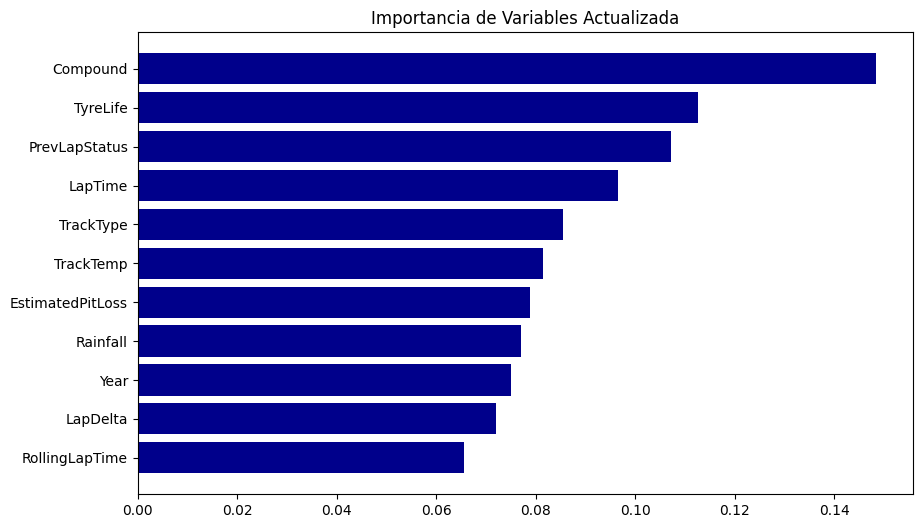

In [7]:
import matplotlib.pyplot as plt

# 5. IMPORTANCIA DE VARIABLES (Para ver si EstimatedPitLoss ayuda)
plt.figure(figsize=(10, 6))
importances = model_pit.feature_importances_
indices = np.argsort(importances)
plt.title("Importancia de Variables Actualizada")
plt.barh(range(len(indices)), importances[indices], color='darkblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.show()

# PRUEBA DE CARRERA

In [9]:
import fastf1
import pandas as pd

# 1. CARGAR CARRERA PARA TEST (Una que no esté en tu entrenamiento si es posible)
# --- SIMULACIÓN CORREGIDA (MÉTODO MANUAL) ---
year_test = 2024
gp_test = "Mexico City Grand Prix"
driver_to_monitor = "VER" 

print(f"--- Simulando Muro de Boxes: {gp_test} {year_test} ---")
session_test = fastf1.get_session(year_test, gp_test, 'R')
session_test.load(laps=True, telemetry=False, weather=True)

# 1. PREPARAR DATOS CLIMÁTICOS MANUALMENTE
laps = session_test.laps.copy()
weather = session_test.weather_data.copy()

# En lugar de usar get_weather_data(), buscamos el clima más cercano para cada vuelta
def get_closest_weather(lap_time):
    # Buscamos el registro de clima justo antes de que termine la vuelta
    return weather[weather['Time'] <= lap_time].iloc[-1]

weather_rows = []
for _, lap in laps.iterrows():
    try:
        w = get_closest_weather(lap['Time'])
        weather_rows.append(w)
    except:
        # Si falla (vuelta 1), usamos el primer registro de clima
        weather_rows.append(weather.iloc[0])

weather_df = pd.DataFrame(weather_rows).reset_index(drop=True)
raw_test_data = pd.concat([laps.reset_index(drop=True), weather_df[['TrackTemp', 'Rainfall']]], axis=1)

# Añadimos columnas manuales
raw_test_data['Year'] = year_test
raw_test_data['EventName'] = gp_test
raw_test_data['TrackType'] = 'Permanent'

# 2. PROCESAR CON TU FUNCIÓN
test_dataset = build_ml_dataset(raw_test_data)

# 3. SIMULACIÓN VUELTA A VUELTA
driver_laps = test_dataset[test_dataset['Driver'] == driver_to_monitor].sort_values('LapNumber')

print(f"\nMonitoreando a {driver_to_monitor}...")
print(f"{'VUELTA':<8} | {'COMPOUND':<10} | {'VIDA':<6} | {'PROB. PIT':<12} | {'ESTADO'}")
print("-" * 75)

for _, lap_data in driver_laps.iterrows():
    # Preparamos features (asegúrate de que 'features' incluya las nuevas del paso anterior)
    lap_features = pd.DataFrame([lap_data[features]])
    
    # Asegurar categorías
    for col in ['Compound', 'TrackType', 'PrevLapStatus']:
        lap_features[col] = lap_features[col].astype('category')
    
    # Probabilidad
    prob = model_pit.predict_proba(lap_features)[0][1] 
    
    # Marcador real para validar
    real_pit = " <- ENTRO REALMENTE" if lap_data['target_pit'] == 1 else ""
    alerta = " [!!!] BOX" if prob > 0.60 else " OK"

    print(f"{int(lap_data['LapNumber']):<8} | {lap_data['Compound']:<10} | {int(lap_data['TyreLife']):<6} | {prob:.2%}      | {alerta}{real_pit}")

core           INFO 	Loading data for Mexico City Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Mexico City Grand Prix - Race [v3.8.3]


req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...


--- Simulando Muro de Boxes: Mexico City Grand Prix 2024 ---


req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '4', '16', '44', '63', '1', '20', '81', '27', '10', '18', '43', '31', '77', '24', '30', '11', '14', '23', '22']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['55', '4', '16', '44', '63', '1', '20', '81', '27', '10', '18', '43', '31', '77', '24', '30', '11', '14', '23', '22']



Monitoreando a VER...
VUELTA   | COMPOUND   | VIDA   | PROB. PIT    | ESTADO
---------------------------------------------------------------------------
1        | MEDIUM     | 1      | 17.85%      |  OK
2        | MEDIUM     | 2      | 2.06%      |  OK
3        | MEDIUM     | 3      | 8.74%      |  OK
4        | MEDIUM     | 4      | 18.56%      |  OK
5        | MEDIUM     | 5      | 13.71%      |  OK
6        | MEDIUM     | 6      | 24.13%      |  OK
7        | MEDIUM     | 7      | 3.28%      |  OK
8        | MEDIUM     | 8      | 10.42%      |  OK
9        | MEDIUM     | 9      | 32.39%      |  OK
10       | MEDIUM     | 10     | 35.83%      |  OK
11       | MEDIUM     | 11     | 21.89%      |  OK
12       | MEDIUM     | 12     | 27.29%      |  OK
13       | MEDIUM     | 13     | 42.43%      |  OK
14       | MEDIUM     | 14     | 35.40%      |  OK
15       | MEDIUM     | 15     | 53.91%      |  OK
16       | MEDIUM     | 16     | 55.85%      |  OK
17       | MEDIUM     | 17     | 